Here, Uzzal combined Module A code from Hanyang and Cora.
Cora's code: /users/PAS2789/uzzaldash/OSC_Codes_MAC_prediction_model/Cora_Github_au23code/module_a_w_diams.ipynb
(module_a_w_diams_Uzzal_Interactive.ipynb contains explanation of the code)
Hanyang's code: /users/PAS2789/uzzaldash/OSC_Codes_MAC_prediction_model/Module_Model/Module_A_size_dist_w_merge_linux.py

Note: Cora's code deal with an ict file but hanyang's code deal with a sample dataset. I combined their codes based on hanyang's sample dataset because it's comparatively bigdata set. But when we need to work on ict file we will have to look into Cora's code again.

In [31]:
import os
import sys
import arrow
import numpy as np
import pandas as pd
from math import pi
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
from datetime import datetime
from numpy import nan_to_num
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter
import os
import sys
import arrow
import numpy as np
import pandas as pd
from math import pi
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
from datetime import date
from numpy import nan_to_num
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter
import pandas as pd
from datetime import datetime, timedelta

sns.set('notebook', style='ticks', font_scale=1.5, palette='dark')
default_cmap = 'viridis'

histogram plotting function with logarithmic y axis and replace nan value
with number

In [32]:
def heatmap(X, Y, Z, ax=None, logy=True, cbar=True, 
            cmap=default_cmap, fig_kws={},  cbar_kws={}, plot_kws={}, **kwargs):

    # Copy to avoid modifying original data
    Z_plot = Z.copy()

    # get rid of NaNs
    Z_plot = nan_to_num(Z_plot)

    # Set the colorbar min and max based on the min and max of the values
    cbar_min = kwargs.pop('cbar_min', Z_plot.min() if Z_plot.min() > 0.0 else 1.)
    cbar_max = kwargs.pop('cbar_max', Z_plot.max())

    # Set the plot_kws
    plot_kws = dict(dict(norm=LogNorm(vmin=cbar_min, vmax=cbar_max), cmap=cmap), **plot_kws)

    # Set the figure keywords
    fig_kws = dict(dict(figsize=(10,5)), **fig_kws)

    if ax is None:
        plt.figure(**fig_kws)
        ax = plt.gca()

    # Plot the data as a pcolormesh
    im = ax.pcolormesh(X, Y, Z_plot, **plot_kws)

    # Set the ylim to match the data
    ax.set_ylim([Y.min(), Y.max()])

    # Set the axis to be log in the y-axis
    if logy:
        ax.semilogy()
        ax.yaxis.set_major_formatter(ScalarFormatter())

    if cbar:
        # Set the figure keywords
        cbar_kws = dict(dict(label='Distribution'), **cbar_kws)
        clb = plt.colorbar(im, **cbar_kws)
        return ax 

In [33]:
#function purpose: find nearest value (d_N1, d_N2, d_V1, d_V2) in numpy array (instrument measured diameters)
def find_nearest(array, value):
    array = [float(i) for i in array]  # force float
    n = [abs(i-value) for i in array]
    idx = n.index(min(n))
    return idx

In [34]:
## Input
# size_dist_input1 = "/users/PAS2789/uzzaldash/OSC_Codes_MAC_prediction_model/Input datasets/Module A/SMPS_dNdlogdP.csv"
# size_dist_input2 = "/users/PAS2789/uzzaldash/OSC_Codes_MAC_prediction_model/Input datasets/Module A/APS_dNdlogdP.csv"
# size_dist_diameter_input1 = "/users/PAS2789/uzzaldash/OSC_Codes_MAC_prediction_model/Input datasets/Module A/SMPS_diameter.csv"
# size_dist_diameter_input2 = "/users/PAS2789/uzzaldash/OSC_Codes_MAC_prediction_model/Input datasets/Module A/APS_diameter.csv"
# datetime_input = "/users/PAS2789/uzzaldash/OSC_Codes_MAC_prediction_model/Input datasets/Module A/datetime.csv"

size_dist_input = rf"C:\Users\haika\Desktop\May_Research\MAC Model for may dataset\ModuleA\size_dist_input.csv"
size_dist_diameter_input = rf"C:\Users\haika\Desktop\May_Research\MAC Model for may dataset\ModuleA\size_dist_diameter_input.csv"
datetime_input = rf"C:\Users\haika\Desktop\May_Research\MAC Model for may dataset\ModuleA\datetime.csv"

# d_N1=50
# d_N2=200
# d_V1=1000
# d_V2=2500

d_Nx_list = [250.0, 500.0]
d_Vx_list = [250.0, 500.0]

?? Why we are converting logdp to lndp in case of SMPS data but we are not doing the same thing for APS data?

In [35]:
# Read number distribution data form two different instrument
# SMPS_dNdlogdP = pd.read_csv(size_dist_input1).values
# SMPS_dNdlogdP = SMPS_dNdlogdP/2.303  #CONVERT SMPS: dNdlogdP to dNdlndP
# SMPS_diameter = pd.read_csv(size_dist_diameter_input1)['diameter']

# #load APS data
# APS_dNdlogdP = pd.read_csv(size_dist_input2).values
# APS_diameter = pd.read_csv(size_dist_diameter_input2)['diameter']   


dNdlogdP = pd.read_csv(size_dist_input).values
diameter = pd.read_csv(size_dist_diameter_input)['diameter']


#Filter out NaN values from dNdlogdP

In [36]:
#IMPORTANT: Filter out all-NaN columns

# Assuming dNdlogdP is a NumPy array
# Mask columns that are NOT all NaN
mask = ~np.all(np.isnan(dNdlogdP), axis=0)

# Filter out all-NaN columns
dNdlogdP = dNdlogdP[:, mask]

#PRINT diameter and dNdlogdP as test
print(dNdlogdP.shape[1])

#print(diameter)

1382863


In [ ]:
#merge SMPS and APS data
# if max(SMPS_diameter) > min(APS_diameter):
#     new_end_SMPS_diameter = find_nearest(SMPS_diameter,min(APS_diameter))
#     SMPS_diameter=SMPS_diameter[:new_end_SMPS_diameter+2]
#     SMPS_dNdlogdP=SMPS_dNdlogdP[:new_end_SMPS_diameter+2,:]
#     APS_diameter=APS_diameter[1:]
#     APS_dNdlogdP=APS_dNdlogdP[1:,:]

In [37]:
# SMPS_dNdlogdP = pd.DataFrame(SMPS_dNdlogdP)
# APS_dNdlogdP = pd.DataFrame(APS_dNdlogdP)
# Concatenate two df along rows (default:axis=0)
# ignore_index= reassign new interger based indices form 0 to ..
size_dist_input = pd.DataFrame(dNdlogdP)
size_dist_diameter_input = pd.DataFrame(diameter)
size_dist_input

,0,1,2,3,4,5,6,7,8,9,...,1382853,1382854,1382855,1382856,1382857,1382858,1382859,1382860,1382861,1382862
0,426.519645,1959.874439,2805.562142,3154.796761,3109.291186,2973.576729,2292.178418,1655.311625,1285.390675,974.567011,...,779.65,832.78,815.12,1201.96,878.54,1298.38,965.05,776.98,908.41,1051.50
1,25.284722,38.057181,40.996420,43.666011,43.556114,46.674498,43.222605,41.091063,37.764797,38.795454,...,188.31,342.09,187.89,529.87,580.95,547.75,324.37,376.41,393.71,563.93
2,24.662611,34.890924,42.461946,46.866915,48.784739,50.242463,49.541256,47.117946,45.900674,44.977239,...,50.91,203.42,228.92,483.37,559.17,789.65,533.39,610.87,509.08,533.53
3,13.950923,19.450279,25.459321,29.733829,29.843400,33.112012,31.332289,29.553218,28.060858,29.202995,...,152.00,168.77,286.20,607.37,623.23,1013.88,572.75,607.21,675.49,573.21
4,7.165081,10.293118,14.910851,17.794278,17.598544,20.368700,18.197614,17.380989,17.421502,17.691928,...,50.24,83.66,234.06,200.81,334.26,385.25,267.27,418.34,401.65,384.41
5,6.602805,8.679930,11.966347,13.772148,14.078815,15.445152,14.811406,14.874957,14.305094,14.540695,...,40.99,25.00,49.98,138.88,81.84,146.00,179.55,166.09,173.03,270.53
6,4.377505,5.085815,6.514462,7.613747,7.759848,8.418198,8.639399,8.165211,8.674107,8.820991,...,66.78,67.31,27.38,118.67,91.74,186.80,134.41,131.87,146.15,91.75
7,1.491482,1.772736,2.505871,2.444095,2.627455,2.712520,3.104030,3.067915,3.310773,3.066925,...,56.93,38.53,57.70,113.60,19.06,115.99,94.89,169.91,97.27,58.60
8,0.806769,0.965743,1.100285,1.344189,1.674597,1.502771,1.552244,1.393203,1.991395,1.673804,...,0.00,0.00,0.00,17.15,17.13,34.79,0.00,0.00,0.00,0.00
9,0.305654,0.513341,0.843556,0.867590,1.014262,0.879878,1.062924,1.051191,1.135755,1.087496,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21.72,0.00,0.00


In [38]:
# make sure properly formatted
# Adopted From Cora's code
size_dist_diameter_input.reset_index(drop=True)
size_dist_diameter_input = size_dist_diameter_input.astype(float)

print(size_dist_diameter_input)
print(size_dist_input)

    diameter
0      150.0
1      169.8
2      192.1
3      217.5
4      246.1
5      278.6
6      315.3
7      356.8
8      403.9
9      457.1
10     517.3
11     585.5
12     662.7
13     750.0
       0            1            2            3            4        \
0   426.519645  1959.874439  2805.562142  3154.796761  3109.291186   
1    25.284722    38.057181    40.996420    43.666011    43.556114   
2    24.662611    34.890924    42.461946    46.866915    48.784739   
3    13.950923    19.450279    25.459321    29.733829    29.843400   
4     7.165081    10.293118    14.910851    17.794278    17.598544   
5     6.602805     8.679930    11.966347    13.772148    14.078815   
6     4.377505     5.085815     6.514462     7.613747     7.759848   
7     1.491482     1.772736     2.505871     2.444095     2.627455   
8     0.806769     0.965743     1.100285     1.344189     1.674597   
9     0.305654     0.513341     0.843556     0.867590     1.014262   
10    0.330148     0.293337     0.5

In [39]:
#find nearest index in size_dist_diameter_input based on user defined d_N & d_V
d_Nx_nearest = []
d_Vx_nearest = []

# len(d_Nx_list)=2 so in in range(0, 2)
for i in range(len(d_Nx_list)):
    x = find_nearest(size_dist_diameter_input['diameter'], d_Nx_list[i])
    d_Nx_nearest.append(x)
for i in range(len(d_Vx_list)):
    x = find_nearest(size_dist_diameter_input['diameter'], d_Vx_list[i])
    d_Vx_nearest.append(x)
d_Nx_nearest, d_Vx_nearest

([4, 10], [4, 10])

In [40]:
# From Cora's code
# Add beginning and ending indexes for the divisions
# (bin1= 0~d_N1, bin2=d_N1~d_N2, bin3= >d_N2)
# Here, beginning index=0, ending index=30 so it will look like [0,6,12,30]
d_Nx_nearest.insert(0,0)
d_Nx_nearest.append(len(size_dist_diameter_input))  
d_Vx_nearest.insert(0,0)
d_Vx_nearest.append(len(size_dist_diameter_input))
d_Nx_nearest, d_Vx_nearest

([0, 4, 10, 14], [0, 4, 10, 14])

In [41]:
# Need to know more why we take dN/dlog(dp)?
# Logarithmic scaling is often used in scientific data when there's a large range of values, especially when the data spans many orders of magnitude.
# It helps in visualizing data that follows a power-law distribution.
ln_size_dist_diameter_input=np.log(size_dist_diameter_input)
ln_size_dist_diameter_input

,diameter
0,5.010635
1,5.134621
2,5.258016
3,5.382199
4,5.505738
5,5.629777
6,5.753525
7,5.877175
8,6.001167
9,6.124902


In [42]:
#replace all input values less than 0 with np.nan
#FIXME: consider LLOD of instrument instead instead of 0
size_dist_input.mask(size_dist_input <= 0, np.nan , inplace=True )
size_dist_input

,0,1,2,3,4,5,6,7,8,9,...,1382853,1382854,1382855,1382856,1382857,1382858,1382859,1382860,1382861,1382862
0,426.519645,1959.874439,2805.562142,3154.796761,3109.291186,2973.576729,2292.178418,1655.311625,1285.390675,974.567011,...,779.65,832.78,815.12,1201.96,878.54,1298.38,965.05,776.98,908.41,1051.50
1,25.284722,38.057181,40.996420,43.666011,43.556114,46.674498,43.222605,41.091063,37.764797,38.795454,...,188.31,342.09,187.89,529.87,580.95,547.75,324.37,376.41,393.71,563.93
2,24.662611,34.890924,42.461946,46.866915,48.784739,50.242463,49.541256,47.117946,45.900674,44.977239,...,50.91,203.42,228.92,483.37,559.17,789.65,533.39,610.87,509.08,533.53
3,13.950923,19.450279,25.459321,29.733829,29.843400,33.112012,31.332289,29.553218,28.060858,29.202995,...,152.00,168.77,286.20,607.37,623.23,1013.88,572.75,607.21,675.49,573.21
4,7.165081,10.293118,14.910851,17.794278,17.598544,20.368700,18.197614,17.380989,17.421502,17.691928,...,50.24,83.66,234.06,200.81,334.26,385.25,267.27,418.34,401.65,384.41
5,6.602805,8.679930,11.966347,13.772148,14.078815,15.445152,14.811406,14.874957,14.305094,14.540695,...,40.99,25.00,49.98,138.88,81.84,146.00,179.55,166.09,173.03,270.53
6,4.377505,5.085815,6.514462,7.613747,7.759848,8.418198,8.639399,8.165211,8.674107,8.820991,...,66.78,67.31,27.38,118.67,91.74,186.80,134.41,131.87,146.15,91.75
7,1.491482,1.772736,2.505871,2.444095,2.627455,2.712520,3.104030,3.067915,3.310773,3.066925,...,56.93,38.53,57.70,113.60,19.06,115.99,94.89,169.91,97.27,58.60
8,0.806769,0.965743,1.100285,1.344189,1.674597,1.502771,1.552244,1.393203,1.991395,1.673804,...,NaN,NaN,NaN,17.15,17.13,34.79,NaN,NaN,NaN,NaN
9,0.305654,0.513341,0.843556,0.867590,1.014262,0.879878,1.062924,1.051191,1.135755,1.087496,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.72,NaN,NaN


In [43]:
#calculate volume distribution based on diameter^3
diameter_power = np.power(size_dist_diameter_input, 3)
diameter_power

,diameter
0,3.375000e+06
1,4.895680e+06
2,7.088953e+06
3,1.028911e+07
4,1.490510e+07
5,2.162436e+07
6,3.134526e+07
7,4.542287e+07
8,6.589031e+07
9,9.550666e+07


In [44]:
# making it as numpy array
diameter_power = diameter_power.to_numpy()
diameter_power

array([[3.37500000e+06],
       [4.89568039e+06],
       [7.08895296e+06],
       [1.02891094e+07],
       [1.49050982e+07],
       [2.16243637e+07],
       [3.13452626e+07],
       [4.54228664e+07],
       [6.58903113e+07],
       [9.55066614e+07],
       [1.38429113e+08],
       [2.00715401e+08],
       [2.91038814e+08],
       [4.21875000e+08]])

In [45]:
# Calculate size_dist_volume
# When you specify axis='index', it means that each row in the DataFrame will be multiplied by
# the corresponding value in the diameter_power Series

size_dist_volume = pi/6*size_dist_input.mul(diameter_power,axis='index')

In [46]:
# Make NaN value to 0
size_dist_input[np.isnan(size_dist_input)] = 0 
size_dist_volume[np.isnan(size_dist_volume)] = 0
size_dist_volume

,0,1,2,3,4,5,6,7,8,9,...,1382853,1382854,1382855,1382856,1382857,1382858,1382859,1382860,1382861,1382862
0,7.537224e+08,3.463384e+09,4.957838e+09,5.574986e+09,5.494571e+09,5.254744e+09,4.050614e+09,2.925177e+09,2.271473e+09,1.722202e+09,...,1.377755e+09,1.471644e+09,1.440436e+09,2.124039e+09,1.552508e+09,2.294427e+09,1.705384e+09,1.373037e+09,1.605293e+09,1.858154e+09
1,6.481415e+07,9.755472e+07,1.050891e+08,1.119322e+08,1.116505e+08,1.196441e+08,1.107956e+08,1.053317e+08,9.680523e+07,9.944719e+07,...,4.827086e+08,8.769040e+08,4.816320e+08,1.358254e+09,1.489191e+09,1.404087e+09,8.314811e+08,9.648790e+08,1.009225e+09,1.445563e+09
2,9.154187e+07,1.295070e+08,1.576089e+08,1.739591e+08,1.810776e+08,1.864883e+08,1.838856e+08,1.748908e+08,1.703726e+08,1.669450e+08,...,1.889661e+08,7.550477e+08,8.496977e+08,1.794157e+09,2.075509e+09,2.930997e+09,1.979819e+09,2.267407e+09,1.889586e+09,1.980339e+09
3,7.515872e+07,1.047858e+08,1.371587e+08,1.601870e+08,1.607773e+08,1.783865e+08,1.687985e+08,1.592140e+08,1.511741e+08,1.573272e+08,...,8.188795e+08,9.092256e+08,1.541864e+09,3.272124e+09,3.357568e+09,5.462142e+09,3.085613e+09,3.271262e+09,3.639111e+09,3.088092e+09
4,5.591838e+07,8.033049e+07,1.163686e+08,1.388717e+08,1.373442e+08,1.589633e+08,1.420195e+08,1.356463e+08,1.359625e+08,1.380730e+08,...,3.920876e+08,6.529070e+08,1.826672e+09,1.567180e+09,2.608662e+09,3.006603e+09,2.085853e+09,3.264847e+09,3.134594e+09,3.000048e+09
5,7.476019e+07,9.827842e+07,1.354888e+08,1.559350e+08,1.594072e+08,1.748776e+08,1.677020e+08,1.684216e+08,1.619693e+08,1.646369e+08,...,4.641089e+08,2.830623e+08,5.658981e+08,1.572467e+09,9.266326e+08,1.653084e+09,2.032953e+09,1.880552e+09,1.959131e+09,3.063073e+09
6,7.184510e+07,8.347013e+07,1.069176e+08,1.249594e+08,1.273573e+08,1.381623e+08,1.417928e+08,1.340102e+08,1.423624e+08,1.447731e+08,...,1.096016e+09,1.104715e+09,4.493699e+08,1.947653e+09,1.505668e+09,3.065825e+09,2.205983e+09,2.164295e+09,2.398664e+09,1.505832e+09
7,3.547245e+07,4.216161e+07,5.959803e+07,5.812879e+07,6.248970e+07,6.451284e+07,7.382425e+07,7.296533e+07,7.874129e+07,7.294178e+07,...,1.353987e+09,9.163728e+08,1.372300e+09,2.701789e+09,4.533108e+08,2.758632e+09,2.256803e+09,4.041030e+09,2.313407e+09,1.393705e+09
8,2.783359e+07,3.331821e+07,3.795993e+07,4.637463e+07,5.777373e+07,5.184571e+07,5.355255e+07,4.806562e+07,6.870329e+07,5.774639e+07,...,0.000000e+00,0.000000e+00,0.000000e+00,5.916765e+08,5.909865e+08,1.200258e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,1.528491e+07,2.567075e+07,4.218387e+07,4.338571e+07,5.072039e+07,4.400022e+07,5.315382e+07,5.256711e+07,5.679591e+07,5.438259e+07,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.086156e+09,0.000000e+00,0.000000e+00


In [47]:
# create empty dataframes with  (num_columns in size_dist_input) x (number_bins) 
# e.g., 5760x3: That means we are converting 30 bins into 3 bins each contains 5760 values
num_bins = len(d_Nx_list) + 1
N_df = pd.DataFrame(index = range(np.size(size_dist_input,1)), columns = range(num_bins))
F_N_df = pd.DataFrame(index = range(np.size(size_dist_input,1)), columns = range(num_bins))
V_df = pd.DataFrame(index = range(np.size(size_dist_input,1)), columns = range(num_bins))
F_V_df = pd.DataFrame(index = range(np.size(size_dist_input,1)), columns = range(num_bins))
F_V_df

,0,1,2
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
1382858,NaN,NaN,NaN
1382859,NaN,NaN,NaN
1382860,NaN,NaN,NaN
1382861,NaN,NaN,NaN


In [48]:
#for each bin, make a smaller dataframe with the diameter bins desired. Then apply trapz calculation by row
#and add result to dataframe in adjacent bin
# here, num_bins=3 so, i == 0, 1, 2
for i in range(num_bins):
    if i == 0:
        #size_dist_input (30*186) > 30 bins > column contains number concentrations (dN/dlogDp)
        # for first bin(i==0), we are cutting rows=0:6, column=all in a small df
        # N_df (186*3)
        # how np.trapz works?
        # small_df has values in 6 rows > y(x); x also contains 6 diameter, so operation in one column at a time
        # When axis=0 is used: The integration will be performed along each column.
        # suppose, 6 diameter (1,2,3,4,5,6) and first column in samll_df is (10,20,30,40,50,60)
        # np.trapz> 1/2[(10+20)*(2-1)+(20+30)*(3-2)+(30+40)*(4-3)+(40+50)*(5-4)+(50+60)*(6-5)]=175
        # Trapezoidal area under the curve=(1/2)(f(x0)+f(x1))(x1-x0)
        # N_df[0,0] = 175, N_df[1,0] come from the second column
        # In this example, V_df[:,2]=0 because in the last bean there are only one row exit which contains 0 in each column.
        small_df = size_dist_input.iloc[0:(d_Nx_nearest[i+1] + 1), :]
        N_df.iloc[:, i] = np.trapz(
            small_df,
            x=ln_size_dist_diameter_input[0:(d_Nx_nearest[i+1] + 1)],
            axis=0
        )
    elif i > 0:
        small_df = size_dist_input.iloc[(d_Nx_nearest[i] + 1):(d_Nx_nearest[i+1] + 1), :]
        N_df.iloc[:, i] = np.trapz(
            small_df,
            x=ln_size_dist_diameter_input[(d_Nx_nearest[i] + 1):(d_Nx_nearest[i+1] + 1)],
            axis=0
        )
N_df

,0,1,2
0,34.792218,1.292881,0.016652
1,133.56982,1.586954,0.031798
2,188.326814,2.129693,0.085509
3,211.559953,2.424106,0.136956
4,208.964219,2.5384,0.11573
...,...,...,...
1382858,395.368539,50.811822,0.0
1382859,253.425992,39.485248,0.0
1382860,271.394748,51.277846,1.260237
1382861,276.508161,40.828755,0.0


In [49]:
# Similarly, calculate V_df
# In this example, V_df[:,2]=0 because in the last bean there are only one row exit which contains 0 in each column.
for i in range(num_bins):
    if i == 0:
        # Include d_Vx_nearest[i+1]
        small_df = size_dist_volume.iloc[0:(d_Vx_nearest[i+1] + 1), :]
        V_df.iloc[:, i] = np.trapz(
            small_df,
            x=ln_size_dist_diameter_input[0:(d_Vx_nearest[i+1] + 1)],
            axis=0
        )
    else:
        # Include d_Vx_nearest[i+1]
        small_df = size_dist_volume.iloc[(d_Vx_nearest[i] + 1):(d_Vx_nearest[i+1] + 1), :]
        V_df.iloc[:, i] = np.trapz(
            small_df,
            x=ln_size_dist_diameter_input[(d_Vx_nearest[i] + 1):(d_Vx_nearest[i+1] + 1)],
            axis=0
        )
V_df

,0,1,2
0,78837534.508871,24724144.417354,2123640.440339
1,260744464.333975,30244882.40665,4464051.768625
2,364036530.347502,41266564.380608,11993201.746511
3,409408136.053329,47306559.368127,19586866.878108
4,405248077.101252,50349081.040544,16432593.352102
...,...,...,...
1382858,1540997579.120478,971768126.276857,0.0
1382859,964676708.943561,678105105.12128,0.0
1382860,1091994248.923626,1088643568.363746,132443773.57594
1382861,1102624184.010662,704380720.583341,0.0


In [50]:
#calculate areaXY_number and volumeXY_number
areaXY_number = pd.Series(np.trapz(size_dist_input, x=ln_size_dist_diameter_input, axis=0))
volumeXY_number = pd.Series(np.trapz(size_dist_volume, x=ln_size_dist_diameter_input, axis=0))
areaXY_number, volumeXY_number

(0           36.985919
 1          136.394793
 2          192.273264
 3          216.177142
 4          213.670739
               ...    
 1382858    479.128248
 1382859    320.622816
 1382860    362.403142
 1382861    352.978312
 1382862    374.180288
 Length: 1382863, dtype: float64,
 0          1.163065e+08
 1          3.090407e+08
 2          4.386162e+08
 3          5.031732e+08
 4          4.980540e+08
                ...     
 1382858    2.801757e+09
 1382859    1.898228e+09
 1382860    2.834507e+09
 1382861    2.122915e+09
 1382862    2.293090e+09
 Length: 1382863, dtype: float64)

In [51]:
#FIXME: question: can we replace 0 with np.nan?
areaXY_number.replace(0, np.nan, inplace=True)
volumeXY_number.replace(0, np.nan, inplace=True)
print(volumeXY_number.head())

0    1.163065e+08
1    3.090407e+08
2    4.386162e+08
3    5.031732e+08
4    4.980540e+08
dtype: float64


In [52]:
#divide N by areaXY for f_N dataframe
for i in range(num_bins):
    F_N_df.iloc[:,i] = N_df.iloc[:,i] / areaXY_number
for i in range(num_bins):
    F_V_df.iloc[:,i] = V_df.iloc[:,i] / volumeXY_number
F_N_df, F_V_df

(                0         1         2
 0        0.940688  0.034956   0.00045
 1        0.979288  0.011635  0.000233
 2        0.979475  0.011076  0.000445
 3        0.978642  0.011214  0.000634
 4        0.977973   0.01188  0.000542
 ...           ...       ...       ...
 1382858  0.825183  0.106051       0.0
 1382859  0.790418  0.123152       0.0
 1382860  0.748875  0.141494  0.003477
 1382861  0.783357  0.115669       0.0
 1382862  0.790332  0.094457  0.003328
 
 [1382863 rows x 3 columns],
                 0         1         2
 0        0.677843  0.212578  0.018259
 1        0.843722  0.097867  0.014445
 2        0.829966  0.094084  0.027343
 3        0.813653  0.094016  0.038927
 4        0.813663  0.101092  0.032994
 ...           ...       ...       ...
 1382858  0.550011  0.346842       0.0
 1382859  0.508198  0.357231       0.0
 1382860   0.38525  0.384068  0.046725
 1382861  0.519391  0.331799       0.0
 1382862   0.48273  0.239138  0.057077
 
 [1382863 rows x 3 columns])

The code chunk below was exist in Hanyang's code. I am not sure these code implemented in cora's code or not. I converted these code in the following cell. Later, we would need to examine wheather its applicabel for more than 3 bins or not.

In [23]:
# If the selected size classes are broader than the measured aerosol sizes 
# print (d_N1,d_N2,d_V1,d_V2,size_dist_diameter_input[len(size_dist_diameter_input)-1])
# if (d_N1 < size_dist_diameter_input[0]):  #only large particles is available
#     N1=0; F_N1=0  
# if (d_N2 > size_dist_diameter_input[len(size_dist_diameter_input)-1]):  #only small particles is available
#     N3=0; F_N3=0
# if (d_V1 < size_dist_diameter_input[0]):
#     V1=0; F_V1=0
# if (d_V2 > size_dist_diameter_input[len(size_dist_diameter_input)-1]):
#     V3=0; F_V=0

In [ ]:
# Check if the selected size classes are outside the measured aerosol sizes
# Ensure the diameter list and size classes are correct
#print(d_Nx_list, d_Vx_list, size_dist_diameter_input[len(size_dist_diameter_input) - 1])

# for i in range(num_bins):
#     if i == 0:  # N1 and V1 (first bin)
#         if d_Nx_list[0] < size_dist_diameter_input[0]:  # If d_Nx_list[0] is less than the smallest diameter in the input
#             N_df.iloc[:, i] = 0  # Set the N1 concentration to 0
#             F_N_df.iloc[:, i] = 0  # Set the F_N1 factor to 0
#         if d_Vx_list[0] < size_dist_diameter_input[0]:  # If d_Vx_list[0] is less than the smallest diameter in the input
#             V_df.iloc[:, i] = 0  # Set V1 concentration to 0
#             F_V_df.iloc[:, i] = 0  # Set the F_V1 factor to 0
#     elif i == num_bins - 1:  # N3 and V3 (last bin)
#         if d_Nx_list[-1] > size_dist_diameter_input[len(size_dist_diameter_input) - 1]:  # If d_Nx_list[-1] is greater than the largest diameter
#             N_df.iloc[:, i] = 0  # Set N3 concentration to 0
#             F_N_df.iloc[:, i] = 0  # Set F_N3 factor to 0
#         if d_Vx_list[-1] > size_dist_diameter_input[len(size_dist_diameter_input) - 1]:  # If d_Vx_list[-1] is greater than the largest diameter
#             V_df.iloc[:, i] = 0  # Set V3 concentration to 0
#             F_V_df.iloc[:, i] = 0  # Set F_V3 factor to 0
#     else:  # For all other bins (middle bins)
#         # Check the conditions for middle bins using d_Nx_list and d_Vx_list (adjust accordingly)
#         pass  # You can further adjust the logic if needed for other bins

# The logic ensures that if the size classes fall outside the range of the aerosol sizes (measured sizes),
# then the respective concentration (N1, N2, V1, V2) and factor (F_N1, F_N2, F_V1, F_V2) will be set to 0.

KeyError: 0

In [53]:
#load SMPS_APS datetime
dateparse = lambda x: datetime.strptime(x, '%m/%d/%Y %H:%M:%S')
datetimedf = pd.read_csv(datetime_input, parse_dates=['datetime_all'], date_parser=dateparse)['datetime_all']

date = str(datetimedf[0])
#Extract first date from the datetime object > '2022_06_18'
date = datetime.strptime(date, '%Y-%m-%d %H:%M:%S').strftime('%Y_%m_%d')
datetimedf

C:\Users\haika\AppData\Local\Temp\ipykernel_6696\380400019.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  datetimedf = pd.read_csv(datetime_input, parse_dates=['datetime_all'], date_parser=dateparse)['datetime_all']


0         2010-06-08 22:29:50
1         2010-06-08 22:36:22
2         2010-06-08 22:38:00
3         2010-06-08 22:39:38
4         2010-06-08 22:41:16
                  ...        
1382858   2017-09-04 19:10:33
1382859   2017-09-04 19:10:43
1382860   2017-09-04 19:10:53
1382861   2017-09-04 19:11:03
1382862   2017-09-04 19:11:13
Name: datetime_all, Length: 1382863, dtype: datetime64[ns]

In [54]:
# Put everything in big dataframe with datetime!
file_M_1 = pd.DataFrame() 
file_M_1['datetime'] = datetimedf
for i in range(num_bins):
    file_M_1['N'+str(i+1)] = N_df.iloc[:,i]
    file_M_1['F_N'+str(i+1)] = F_N_df.iloc[:,i]
    file_M_1['V'+str(i+1)] = V_df.iloc[:,i]
    file_M_1['F_V'+str(i+1)] = F_V_df.iloc[:,i]
file_M_1['V_total'] = volumeXY_number
file_M_1['N_total'] = areaXY_number


#Populate F_N_Total and F_V_Total
# Dynamically generate column names
F_N_cols = [f'F_N{i+1}' for i in range(num_bins)]
F_V_cols = [f'F_V{i+1}' for i in range(num_bins)]

# Calculate the total for F_N and F_V
file_M_1['F_N_Total'] = file_M_1[F_N_cols].sum(axis=1)
file_M_1['F_V_Total'] = file_M_1[F_V_cols].sum(axis=1)

# Create dynamic column lists
N_cols     = [f'N{i+1}' for i in range(num_bins)]
F_N_cols   = [f'F_N{i+1}' for i in range(num_bins)]
V_cols     = [f'V{i+1}' for i in range(num_bins)]
F_V_cols   = [f'F_V{i+1}' for i in range(num_bins)]

# Construct full column order
cols_order = (
    ['datetime'] +
    N_cols + ['N_total'] +
    F_N_cols +
    V_cols + ['V_total'] +
    F_V_cols +
    ['F_N_Total', 'F_V_Total']
)

# Apply to DataFrame
file_M_1 = file_M_1[cols_order]



In [55]:
#export csv
#filepath = 'C:/Users/cphal/OneDrive/Desktop/Aerosols/Module A/Module_A_out/'
export_csv = file_M_1.to_csv (rf'C:\Users\haika\Desktop\May_Research\MAC Model for may dataset\ModuleA\Output_Module_A_w_merge_Cora_integrate.csv', index = None, header=True)

### Visualization

/users/PAS2789/uzzaldash/.conda/envs/mac_prediction_env/lib/python3.7/site-packages/ipykernel_launcher.py:25: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.


Text(0.5, 1.0, '$Number \\ concentration \\; [\\ cm^{-3}]$')

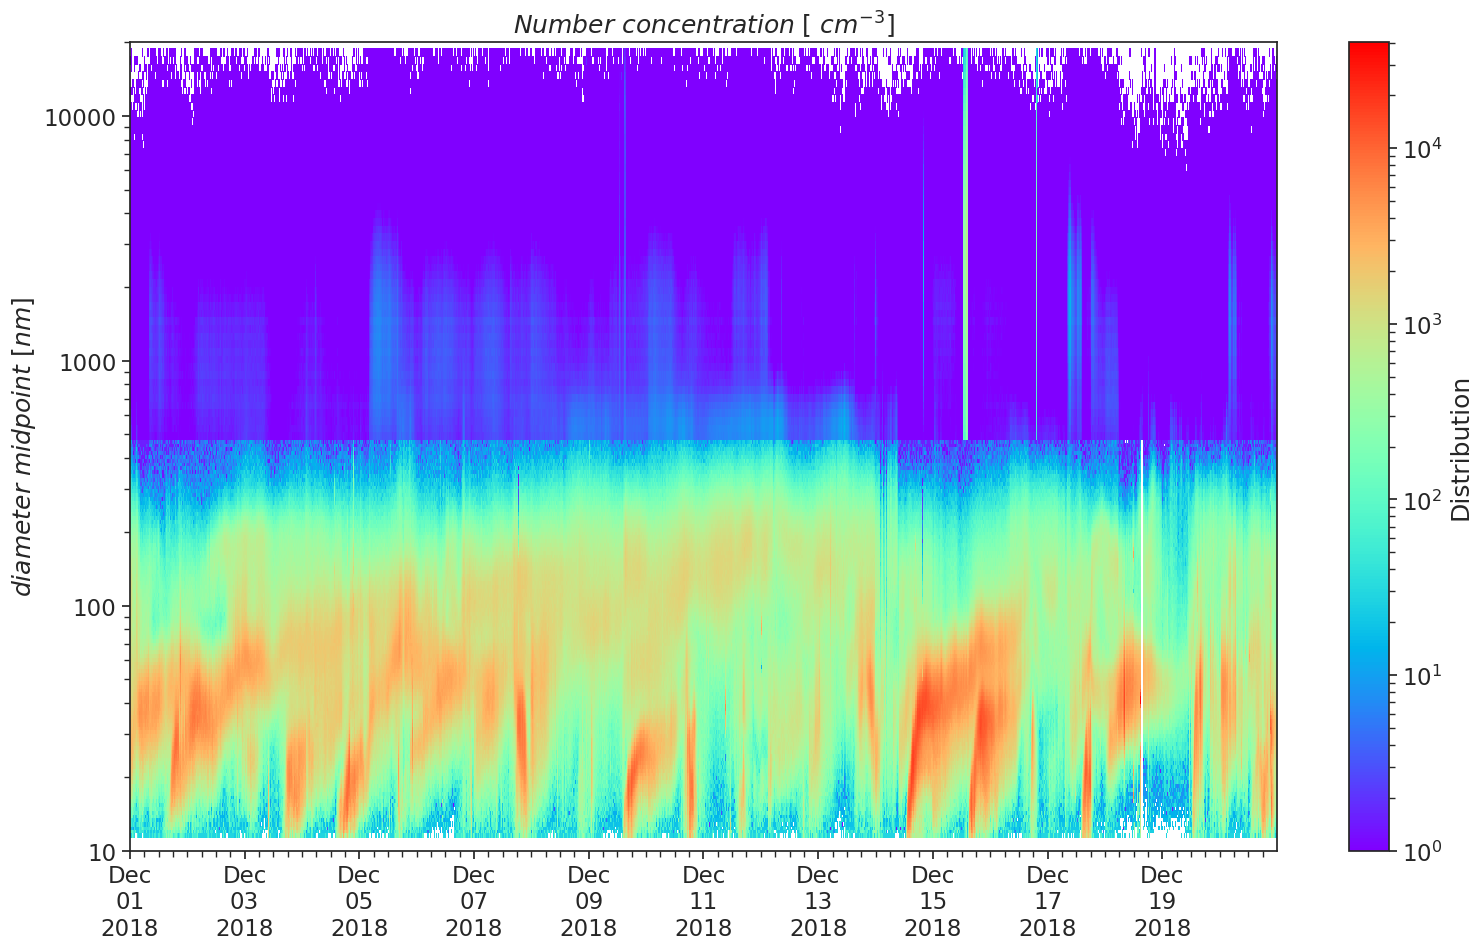

In [28]:
ax = heatmap(datetimedf,size_dist_diameter_input,size_dist_input.values, cmap='rainbow', fig_kws=dict(figsize=(18.5, 10.5)))
ax.set_ylim(10,20000)
start, end = ax.get_ylim()
ax.xaxis.set_minor_locator(dates.HourLocator(byhour=[0, 6, 12, 18]))
ax.xaxis.set_major_formatter(dates.DateFormatter("%b\n%d\n%Y"))
ax.set_ylabel("$diameter \ midpoint \  [nm]$")
plt.title("$Number \ concentration \; [\ cm^{-3}]$")

In [40]:
size_dist_input

,0,1,2,3,4,5,6,7,8,9,...,5750,5751,5752,5753,5754,5755,5756,5757,5758,5759
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.004082,0.003861,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
219,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.003333,0.003333,...,0.000000,0.003861,0.0,0.0,0.0,0.0,0.0,0.0,0.006689,0.0
220,0.0,0.0,0.0,0.0,0.0,0.003333,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.003344,0.0
221,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.003333,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


/users/PAS2789/uzzaldash/.conda/envs/mac_prediction_env/lib/python3.7/site-packages/ipykernel_launcher.py:25: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.


Text(0.5, 1.0, '$Volume \\ concentration \\; [nm^3\\ cm^{-3}]$')

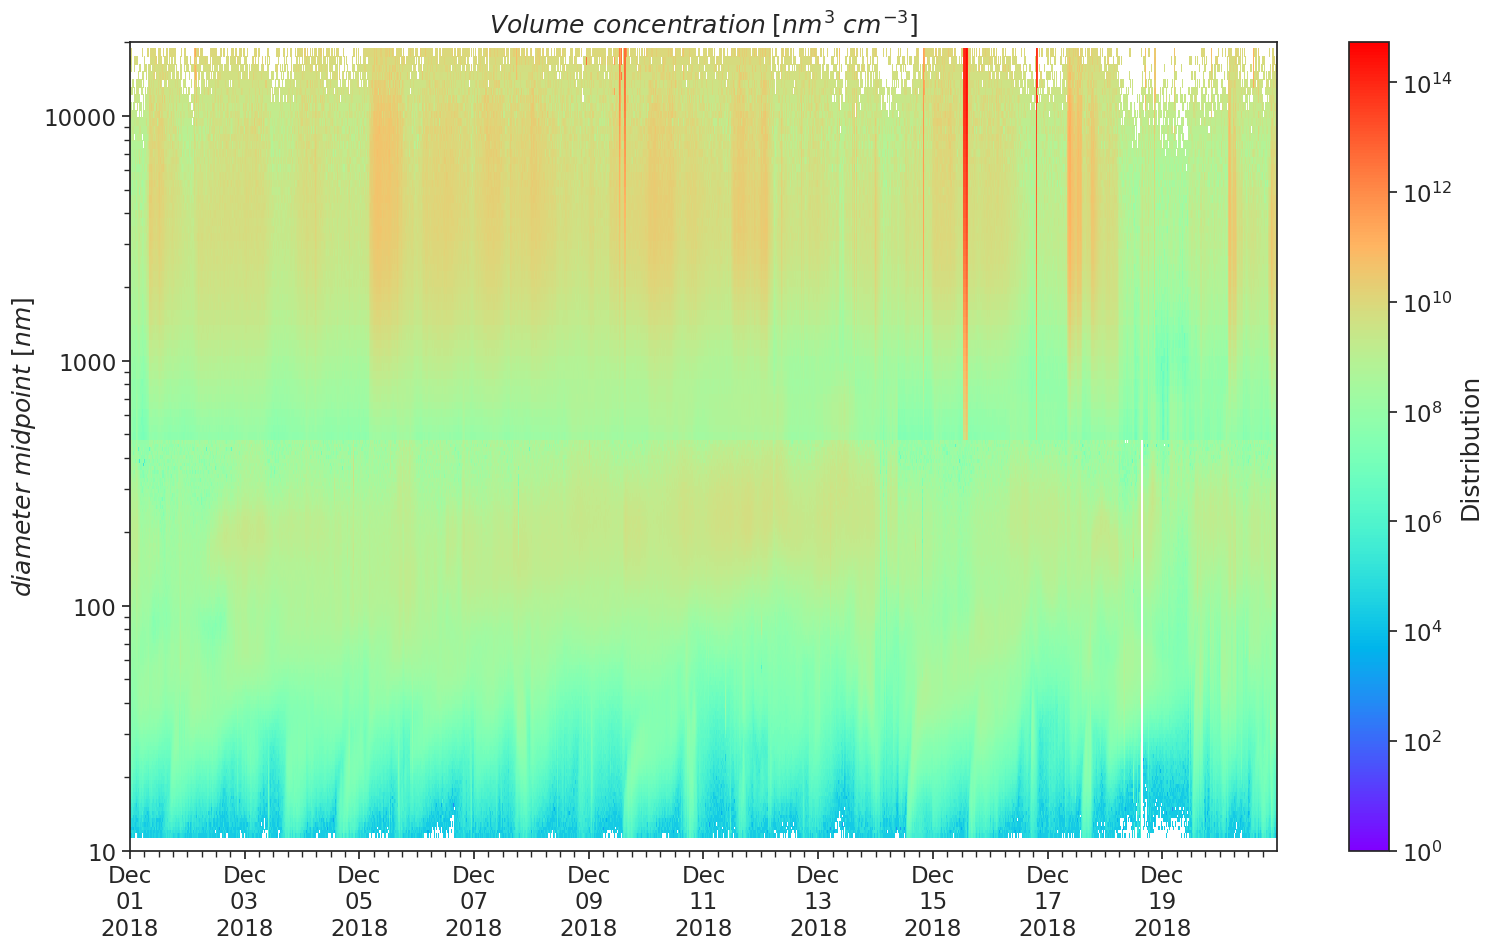

In [29]:
ax = heatmap(datetimedf,size_dist_diameter_input,size_dist_volume.values, cmap='rainbow', fig_kws=dict(figsize=(18.5, 10.5)))
ax.set_ylim(10,20000)
start, end = ax.get_ylim()
ax.xaxis.set_minor_locator(dates.HourLocator(byhour=[0, 6, 12, 18]))
ax.xaxis.set_major_formatter(dates.DateFormatter("%b\n%d\n%Y"))
ax.set_ylabel("$diameter \ midpoint \  [nm]$")
plt.title("$Volume \ concentration \; [nm^3\ cm^{-3}]$")

Text(0.5, 1.0, 'Daily number distribution')

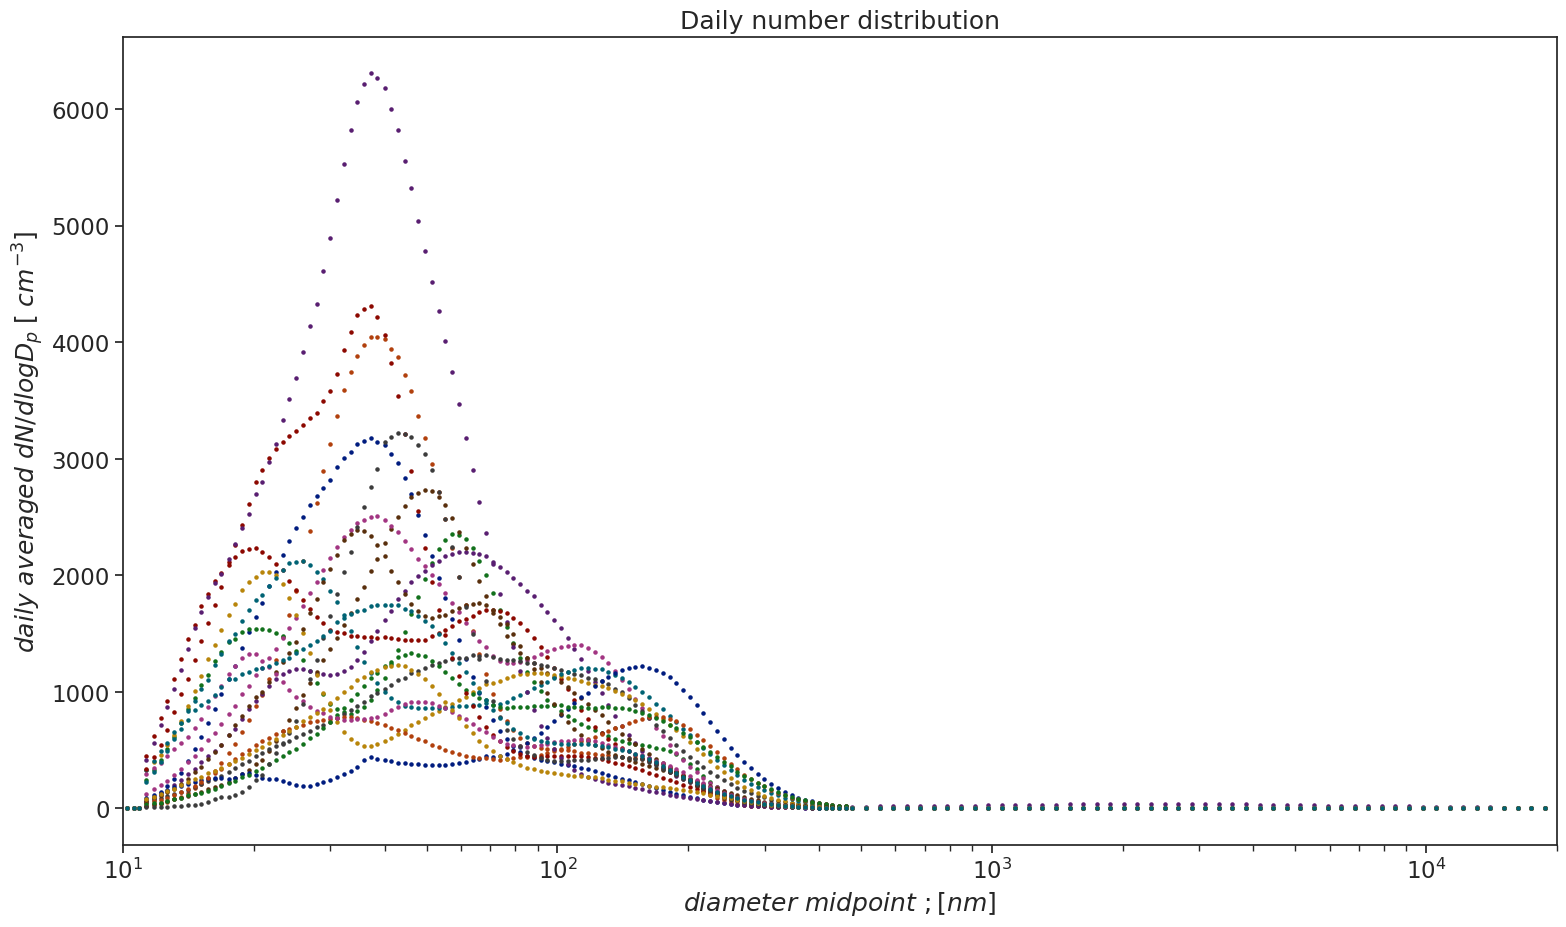

In [30]:
fig =  plt.figure()
fig.set_size_inches(18.5, 10.5)
plt.xlim(10,20000)
plt.ylabel("$daily \ averaged \ dN/dlogD_p \; [\ cm^{-3}]$")
plt.xlabel("$diameter \ midpoint \ ; [nm]$")
delta_days= arrow.get(datetimedf.dt.date[len(datetimedf.dt.date)-1])-arrow.get(datetimedf.dt.date[0])
delta_days=delta_days.days+1
delta_hourly=delta_days*24

for i  in range(delta_days):
    temp = size_dist_input.values[:,i*288:(i+1)*288]  # 288 = 24 * (60/5)
    plt.scatter(size_dist_diameter_input, np.nanmean(temp, axis = 1),s=5)
plt.semilogx()    
plt.title('Daily number distribution')

Looks like the code below will only be applicable for 3 bins. we would need to modify for larger number of bins.

In [31]:
#calculate hourly averaged concentration
N1_hourly = pd.Series(np.zeros(delta_hourly))
N2_hourly = pd.Series(np.zeros(delta_hourly))
N3_hourly = pd.Series(np.zeros(delta_hourly))
areaXY_number_hourly = pd.Series(np.zeros(delta_hourly))
F_N1_hourly = pd.Series(np.zeros(delta_hourly))
F_N2_hourly = pd.Series(np.zeros(delta_hourly))
F_N3_hourly = pd.Series(np.zeros(delta_hourly))
V1_hourly = pd.Series(np.zeros(delta_hourly))
V2_hourly = pd.Series(np.zeros(delta_hourly))
V3_hourly = pd.Series(np.zeros(delta_hourly))
areaXY_volume_hourly = pd.Series(np.zeros(delta_hourly))
F_V1_hourly = pd.Series(np.zeros(delta_hourly))
F_V2_hourly = pd.Series(np.zeros(delta_hourly))
F_V3_hourly = pd.Series(np.zeros(delta_hourly))
date_time_hourly = pd.Series(np.zeros(delta_hourly, dtype='datetime64[s]'))

# Calculate hourly averages using pandas .iloc and .mean
m = 0
for i in range(delta_hourly):
    # For `N_df`, use .iloc and .mean() to calculate the mean for each hour
    areaXY_number_hourly[m] = areaXY_number.iloc[i*12:(i+1)*12].mean(skipna=True)  
    N1_hourly[m] = N_df.iloc[i*12:(i+1)*12, 0].mean(skipna=True)  # Assuming the first column corresponds to N1
    N2_hourly[m] = N_df.iloc[i*12:(i+1)*12, 1].mean(skipna=True)  # Assuming the second column corresponds to N2
    N3_hourly[m] = areaXY_number_hourly[m] - N1_hourly[m] - N2_hourly[m]  # Ensuring sum equals areaXY

    F_N1_hourly[m] = F_N_df.iloc[i*12:(i+1)*12, 0].mean(skipna=True)
    F_N2_hourly[m] = F_N_df.iloc[i*12:(i+1)*12, 1].mean(skipna=True)
    F_N3_hourly[m] = 1 - F_N1_hourly[m] - F_N2_hourly[m]  # Ensuring sum equals 1

    areaXY_volume_hourly[m] = volumeXY_number.iloc[i*12:(i+1)*12].mean(skipna=True)
    V1_hourly[m] = V_df.iloc[i*12:(i+1)*12, 0].mean(skipna=True)
    V2_hourly[m] = V_df.iloc[i*12:(i+1)*12, 1].mean(skipna=True)
    V3_hourly[m] = areaXY_volume_hourly[m] - V1_hourly[m] - V2_hourly[m]  # Ensuring sum equals volumeXY

    F_V1_hourly[m] = F_V_df.iloc[i*12:(i+1)*12, 0].mean(skipna=True)
    F_V2_hourly[m] = F_V_df.iloc[i*12:(i+1)*12, 1].mean(skipna=True)
    F_V3_hourly[m] = 1 - F_V1_hourly[m] - F_V2_hourly[m]  # Ensuring sum equals 1

    # Assuming `date_time` is a pandas series, you can access it by indexing
    date_time_hourly[m] = datetimedf.iloc[i*12]  # Pick the first date in each hour block
    m += 1

# At this point, the `*_hourly` series should contain the hourly averages for the corresponding variables

In [32]:
width=0.03

Text(0.5, 1.0, 'Hourly number concentration')

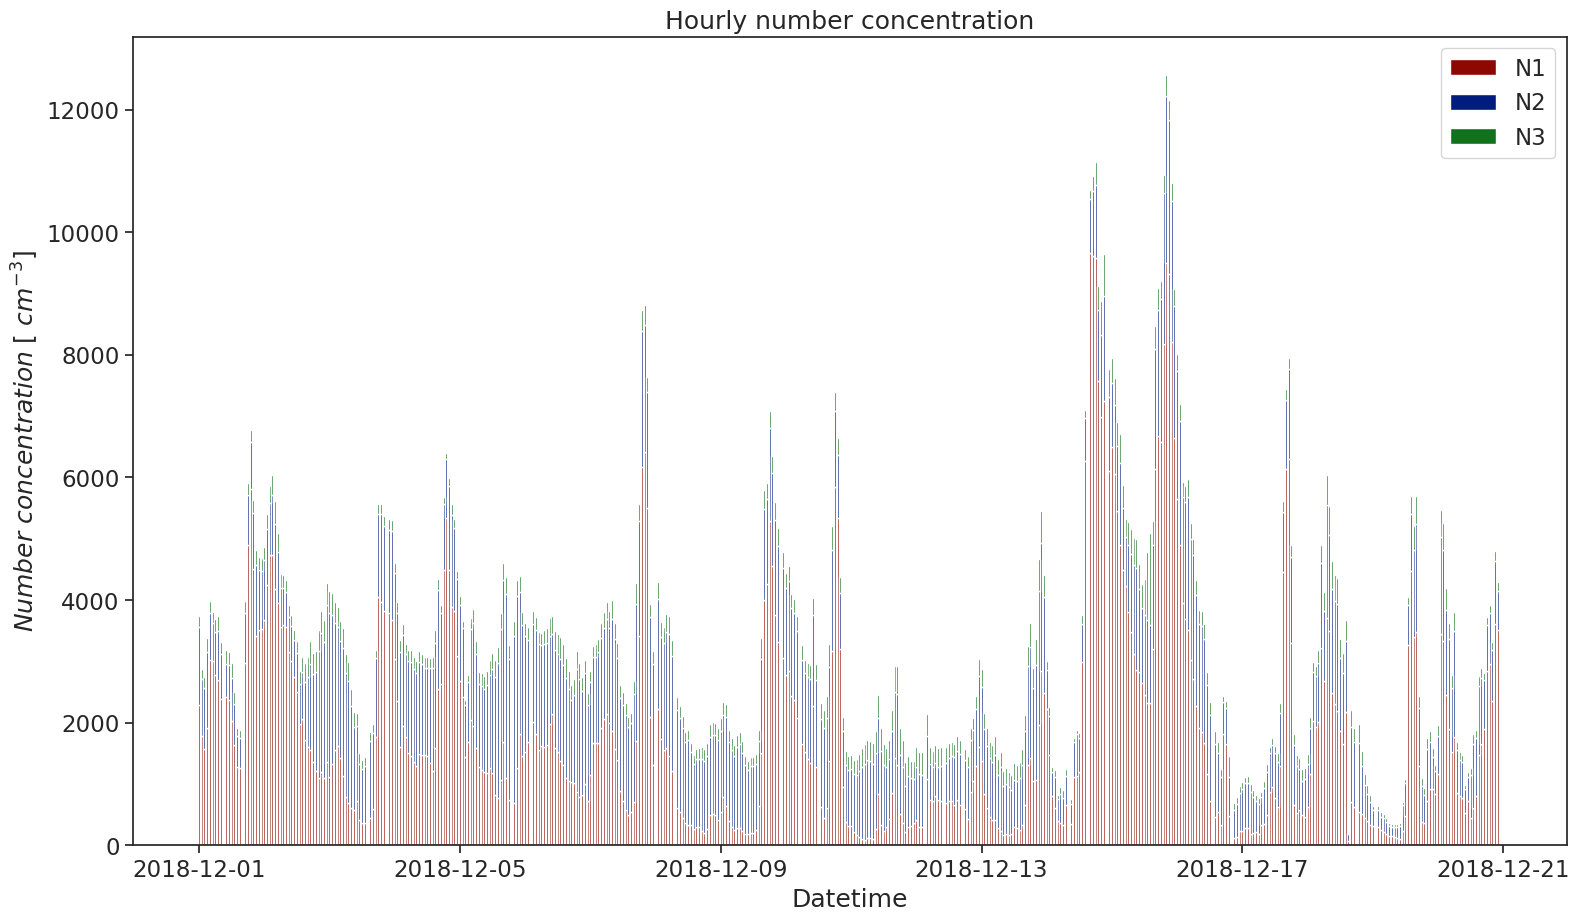

In [33]:
fig =  plt.figure()
fig.set_size_inches(18.5, 10.5)
p1 = plt.bar(date_time_hourly, np.array(N1_hourly),width, color='r')
p2 = plt.bar(date_time_hourly, np.array(N2_hourly), width,bottom=np.array(N1_hourly), color='b')
p3 = plt.bar(date_time_hourly, np.array(N3_hourly), width,bottom=np.array(N1_hourly)+np.array(N2_hourly), color='g')
plt.legend(labels=['N1', 'N2','N3'])
plt.ylabel('Number concentration')
plt.ylabel("$Number \ concentration \; [\ cm^{-3}]$")
plt.xlabel('Datetime')
plt.title('Hourly number concentration')

Text(0.5, 1.0, 'Hourly fractional number concentration')

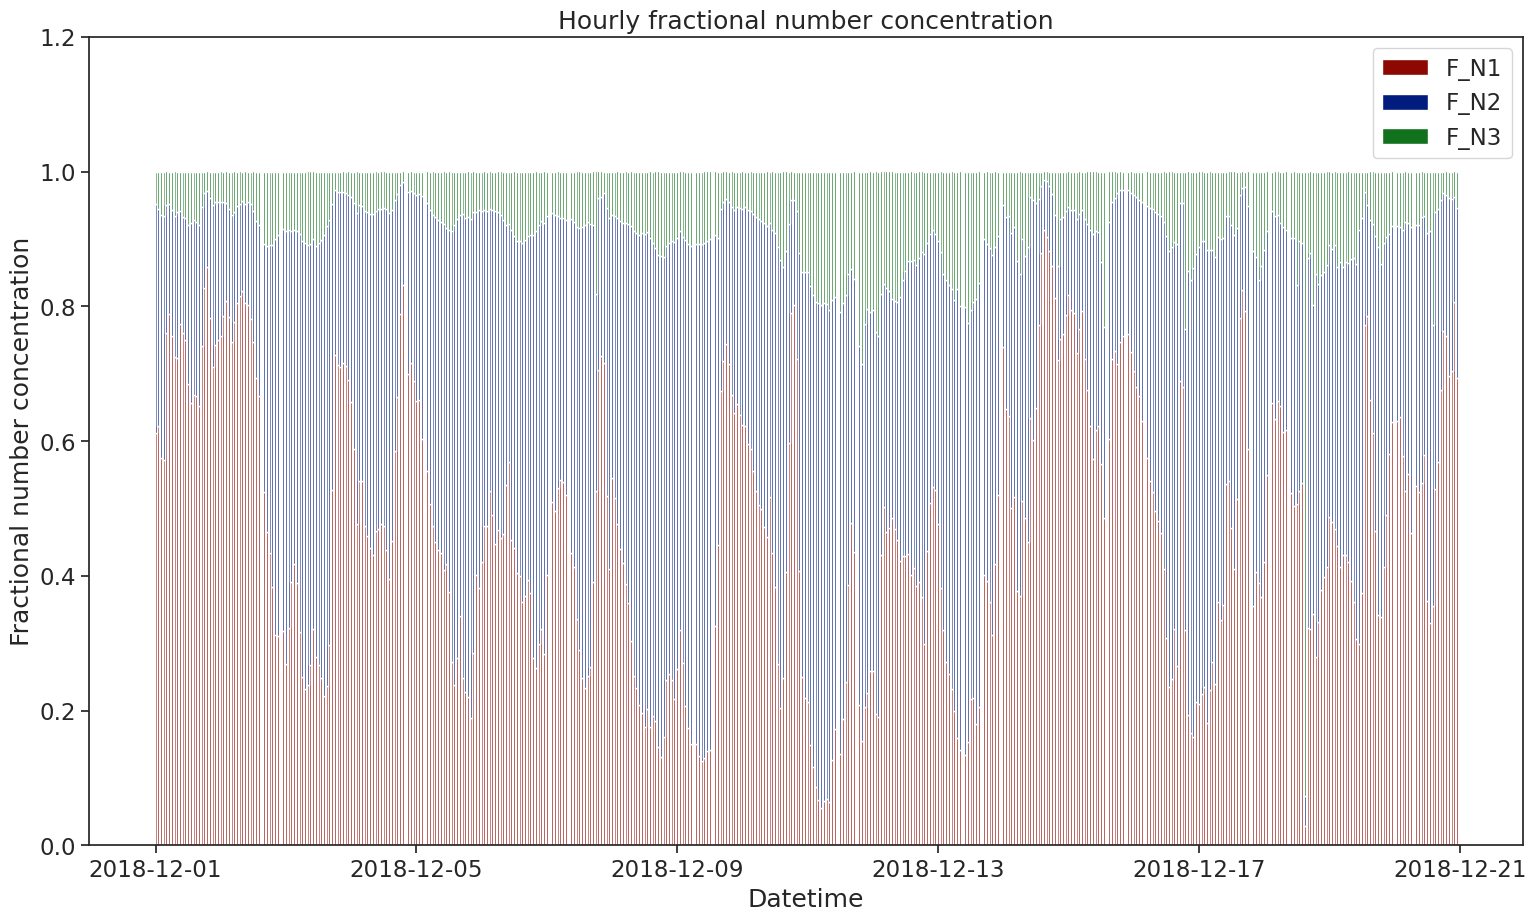

In [34]:
fig =  plt.figure()
fig.set_size_inches(18.5, 10.5)
p1 = plt.bar(date_time_hourly, np.array(F_N1_hourly), width,color='r')
p2 = plt.bar(date_time_hourly, np.array(F_N2_hourly), width,bottom=np.array(F_N1_hourly), color='b')
p3 = plt.bar(date_time_hourly, np.array(F_N3_hourly), width,bottom=np.array(F_N1_hourly)+np.array(F_N2_hourly), color='g')
plt.legend(labels=['F_N1', 'F_N2','F_N3'])
plt.ylim(0,1.2)
plt.ylabel('Fractional number concentration')
plt.xlabel('Datetime')
plt.title('Hourly fractional number concentration')

Text(0.5, 1.0, 'Hourly volume concentration')

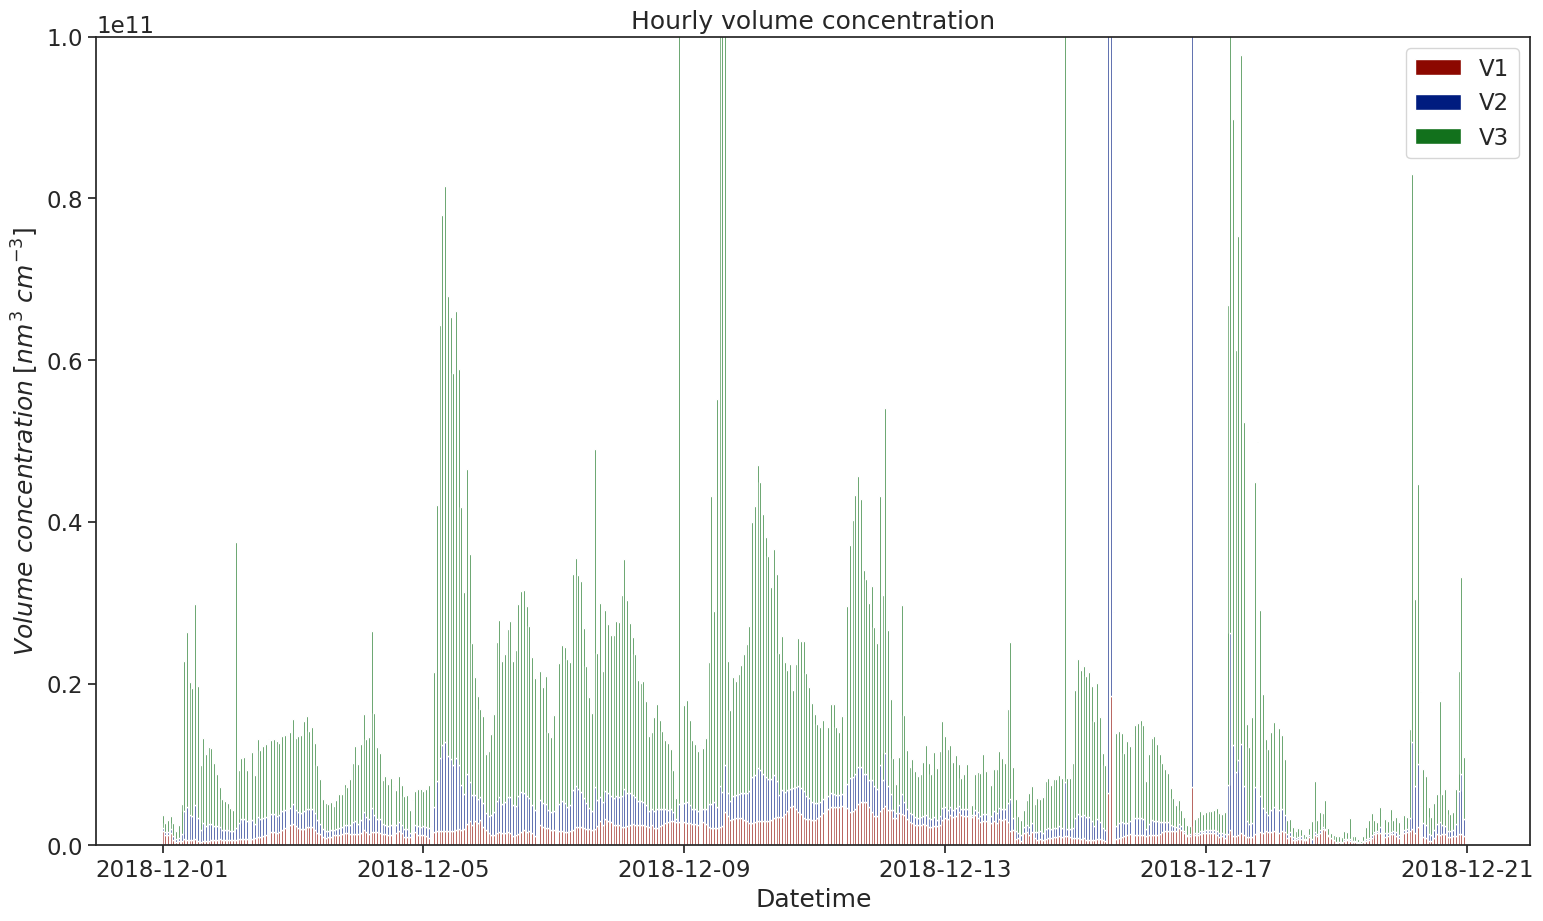

In [35]:
fig =  plt.figure()
fig.set_size_inches(18.5, 10.5)
p1 = plt.bar(date_time_hourly, np.array(V1_hourly),width, color='r')
p2 = plt.bar(date_time_hourly, np.array(V2_hourly), width,bottom=np.array(V1_hourly), color='b')
p3 = plt.bar(date_time_hourly, np.array(V3_hourly), width,bottom=np.array(V1_hourly)+np.array(V2_hourly), color='g')
plt.legend(labels=['V1', 'V2','V3'])
plt.ylim(0,1e11)
plt.ylabel("$Volume \ concentration \; [nm^3\ cm^{-3}]$")
plt.xlabel('Datetime')
plt.title('Hourly volume concentration')

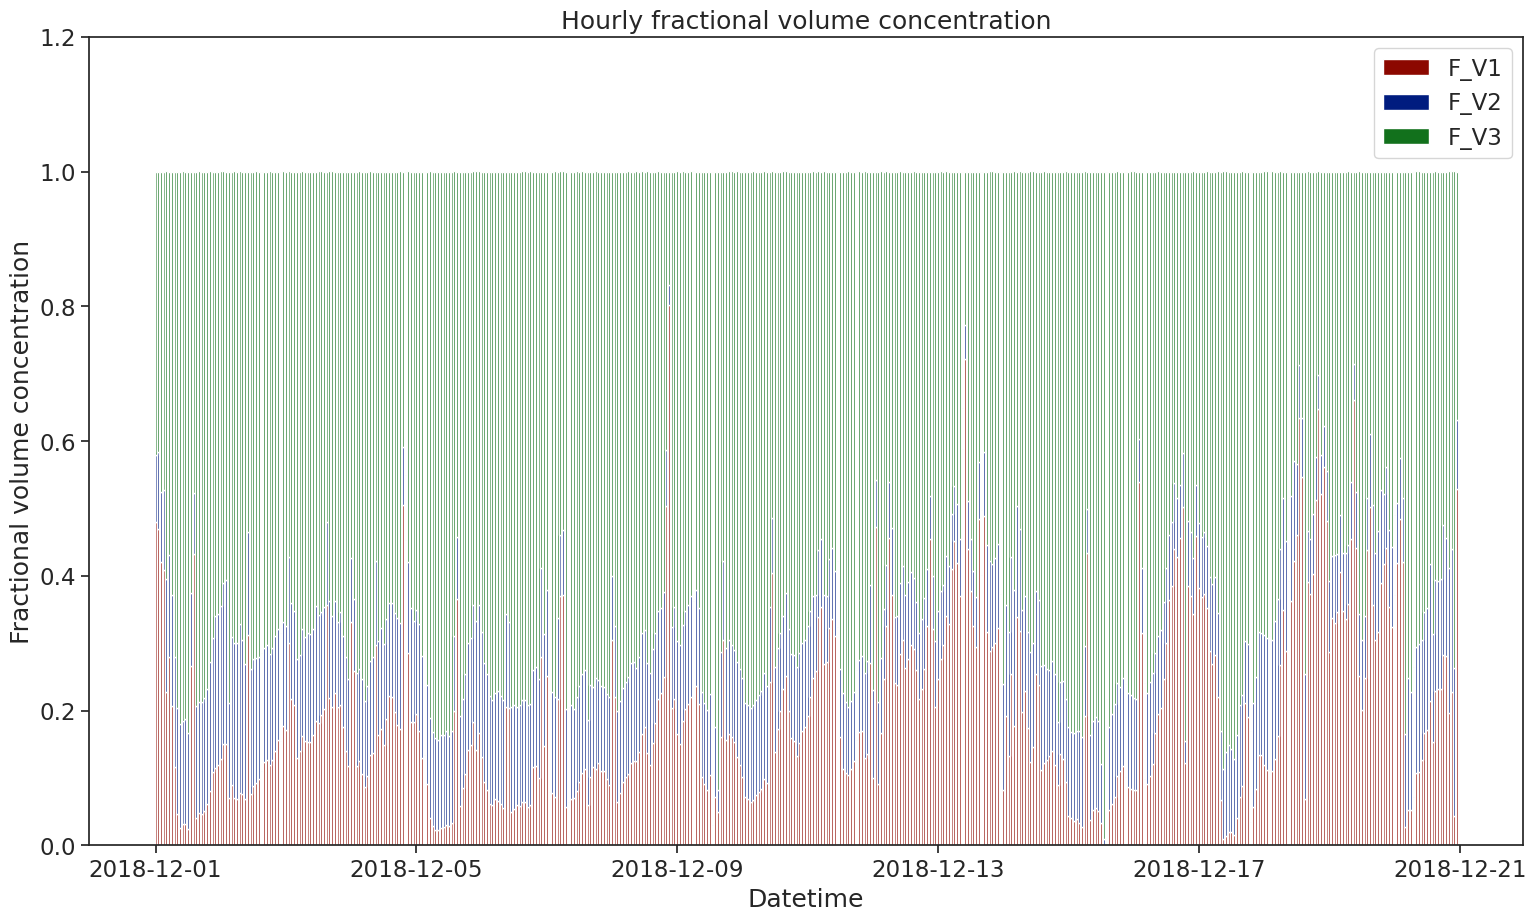

In [36]:
fig =  plt.figure()
fig.set_size_inches(18.5, 10.5)
p1 = plt.bar(date_time_hourly, np.array(F_V1_hourly), width,color='r')
p2 = plt.bar(date_time_hourly, np.array(F_V2_hourly), width,bottom=np.array(F_V1_hourly), color='b')
p3 = plt.bar(date_time_hourly, np.array(F_V3_hourly), width,bottom=np.array(F_V1_hourly)+np.array(F_V2_hourly), color='g')
plt.legend(labels=['F_V1', 'F_V2','F_V3'])
plt.ylim(0,1.2)
plt.ylabel('Fractional volume concentration')
plt.xlabel('Datetime')
plt.title('Hourly fractional volume concentration')
plt.show()